### Load Necesarry Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

### Data Collection & Analysis

In [5]:
# Loading Dataset 
customer_data = pd.read_csv('Mall_Customers.csv')
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# Checking for Missing Values
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [31]:
# Choosing the features for clustering
X = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']]
X[:5]

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


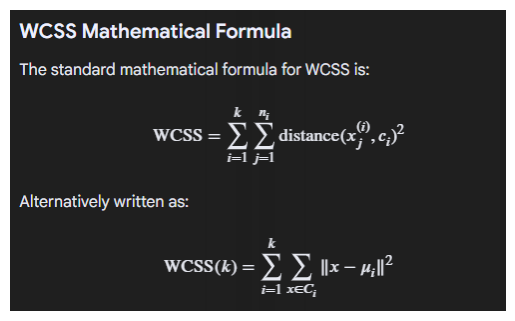

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('Images/wcss.png')
plt.imshow(img)
plt.axis('off')
plt.show()



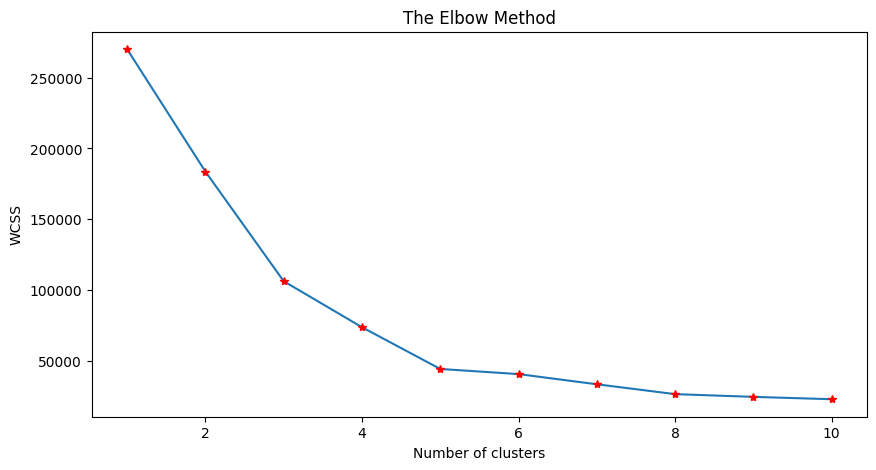

In [33]:
# Choosing no of clusters using Elbow Method
# WCSS (Within-Cluster-Sum-of-Squares)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42) 
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) 
    # inertia_ is the attribute that gives the WCSS value for the fitted model

# Plotting the Elbow Graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='*', markerfacecolor='red', markeredgecolor='red')    
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.savefig("Figures/wcss.png")
plt.show()

#### **Optimal number of clusters is 5 as the WCSS value starts to decrease significantly after that point.**

### Training the K-means Clustering model

In [35]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
X["Cluster"] = y_kmeans
X.head()

C:\Users\user\AppData\Local\Temp\ipykernel_7968\3019047580.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"] = y_kmeans


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


### Visualizing all the clusters

<Figure size 1000x500 with 0 Axes>

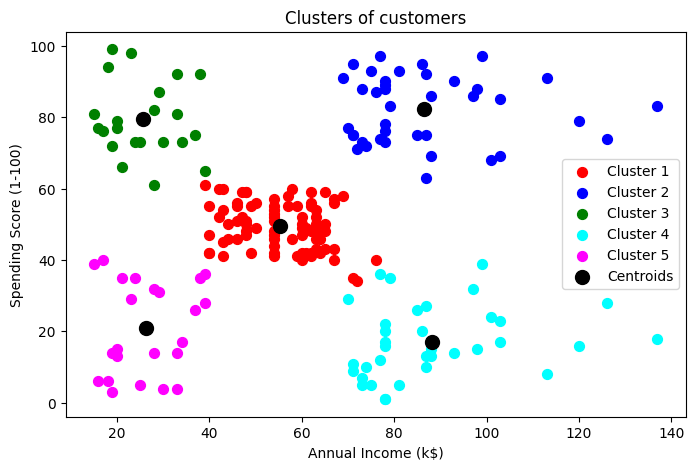

In [37]:
plt.figure(figsize=(10, 5))

plt.figure(figsize=(8,5))

plt.scatter(X.loc[y_kmeans == 0, "Annual Income (k$)"], 
            X.loc[y_kmeans == 0, "Spending Score (1-100)"], 
            s=50, c='red', label='Cluster 1')

plt.scatter(X.loc[y_kmeans == 1, "Annual Income (k$)"], 
            X.loc[y_kmeans == 1, "Spending Score (1-100)"], 
            s=50, c='blue', label='Cluster 2')

plt.scatter(X.loc[y_kmeans == 2, "Annual Income (k$)"], 
            X.loc[y_kmeans == 2, "Spending Score (1-100)"], 
            s=50, c='green', label='Cluster 3')

plt.scatter(X.loc[y_kmeans == 3, "Annual Income (k$)"], 
            X.loc[y_kmeans == 3, "Spending Score (1-100)"], 
            s=50, c='cyan', label='Cluster 4')

plt.scatter(X.loc[y_kmeans == 4, "Annual Income (k$)"], 
            X.loc[y_kmeans == 4, "Spending Score (1-100)"], 
            s=50, c='magenta', label='Cluster 5')

# plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')
# plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')
# plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3')
# plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4')
# plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, c='magenta', label='Cluster 5')


'''
X[y_kmeans == 0, 0]: Filters the dataset X to select the x-coordinates 
    (first column, index 0) for only those rows where the predicted cluster label in y_kmeans is 0.
    
X[y_kmeans == 0, 1]: Filters the dataset X to select the y-coordinates 
    (second column, index 1) for only those same rows belonging to cluster 0.
'''
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='black', label='Centroids')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig("Figures/customer_clusters.png")

plt.show()

### Insights:
- Cluster 1 (Red): Customers with low annual income and low spending score. They are likely to be cautious spenders or budget-conscious customers.
- Cluster 2 (Blue): Customers with high annual income and high spending score. They are likely to be loyal customers who spend a lot and have a high purchasing power.
- Cluster 3 (Green): Customers with high annual income but low spending score. They may be potential customers who have the financial means but are not currently spending much.
- Cluster 4 (Cyan): Customers with low annual income but high spending score. They may be impulsive buyers or customers who prioritize spending on certain products or experiences.
- Cluster 5 (Magenta): Customers with average annual income and average spending score. They may represent a more balanced group of customers who have moderate purchasing power and spending habits.

